In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from datasets import load_dataset
from matplotlib import pyplot as plt
import random
import numpy as np
import time
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score

C:\Users\musae\Desktop\files\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Загрузка данных

In [4]:
ds = load_dataset('uoft-cs/cifar10')
ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [5]:
ds["train"].features

{'img': Image(mode=None, decode=True),
 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}

In [6]:
sample = ds["train"][0]
print(type(sample))
print(sample)

<class 'dict'>
{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x1564F3417D0>, 'label': 0}


In [7]:
class CifarDataset(Dataset):
    def __init__(self, data, transforms):
        self.data = data
        self.transforms = transforms
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]

        image = item['img']
        label = item['label']

        if self.transforms:
            image = self.transforms(image)
        return image, label

In [8]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [9]:
cifar10_train = CifarDataset(ds['train'], transforms=transform_train)

g = torch.Generator()
g.manual_seed(seed)

cifar10_loader_train = DataLoader(
    cifar10_train,
    batch_size=32,
    shuffle=True,
    generator=g
)

In [10]:
cifar10_test = CifarDataset(ds['test'], transforms=transform_test)

cifar10_loader_test = DataLoader(
    cifar10_test, 
    batch_size=128, 
    shuffle=False
)

# Создание модели

In [11]:
class GaussianActivationNoise(nn.Module):
    def __init__(self, sigma, relative):
        super().__init__()
        self.sigma = sigma
        self.relative = relative
    def forward(self, x):
        if not self.training or self.sigma == 0:
            return x
        
        noise = torch.randn_like(x)

        if self.relative:
            scale = x.detach().std()
            return x + self.sigma * scale * noise
        else:
            return x + self.sigma * noise

In [12]:
class Net(nn.Module):
    def __init__(self, sigma1=0, sigma2=0, sigma3=0, relative=True):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 256),
            nn.ReLU(),
            GaussianActivationNoise(sigma3, relative),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)

        return x

# Шум параметров

In [13]:
def get_omega_for_parameter(name, omega1, omega2, omega3):
    if name.startswith('block1'):
        return omega1
    elif name.startswith('block2'):
        return omega2
    else:
        return omega3

# Обучение

In [14]:
num_epochs = 20
lr = 1e-2

In [15]:
criterion = nn.CrossEntropyLoss()

In [16]:
def evaluate(model, val_loader, final=False):
    model.eval()

    correct = 0
    running_loss = 0.0
    
    correct_pred = {i: 0 for i in range(10)}
    total_pred = {i: 0 for i in range(10)}

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            running_loss += loss.item()

            pred = output.argmax(dim=1)

            correct += pred.eq(target.data).sum()

            for label, prediction in zip(target, pred):
                label = label.item()
                prediction = prediction.item()
                if label == prediction:
                    correct_pred[label] += 1
    
                total_pred[label] += 1
                

    accuracy = correct / len(val_loader.dataset)
    avg_loss = running_loss / len(val_loader)

    if final:
        for i in range(10):
            acc = 100 * correct_pred[i] / total_pred[i]
            print(f"Accuracy class {i} = {acc:.1f} %")
        

    return accuracy.cpu().item(), avg_loss

In [17]:
def train(net, num_epochs, omega1, omega2, omega3, relative_params=True):
    losses = []
    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(cifar10_loader_train):
            data = data.to(device)
            target = target.to(device)
            
            optimizer.zero_grad()
    
            net_out = net(data)
            loss = criterion(net_out, target)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                for name, param in net.named_parameters():
                    if param.requires_grad:
                        omega = get_omega_for_parameter(name, omega1, omega2, omega3)
                        if omega > 0:
                            noise = torch.randn_like(param)

                            if relative_params:
                                scale = param.detach().std()
                                param.add_(omega * scale * noise)
                            else:
                                param.add_(omega * noise)
                
            running_loss += loss.item()
        if epoch == num_epochs-1: 
            val_acc, val_loss = evaluate(net, cifar10_loader_test, True)
        else:
            val_acc, val_loss = evaluate(net, cifar10_loader_test)
        losses.append(running_loss/len(cifar10_loader_train))
        print(f'epoch: {epoch+1}, train loss: {running_loss/len(cifar10_loader_train)}, val_acc: {val_acc}, val_loss: {val_loss}')

        plt.plot(losses)
        plt.xlabel("Эпоха")
        plt.ylabel("Loss");

epoch: 1, train loss: 1.878514452996501, val_acc: 0.4293999969959259, val_loss: 1.5198308335074895
epoch: 2, train loss: 1.4306986093978735, val_acc: 0.6227999925613403, val_loss: 1.0334282215637496
epoch: 3, train loss: 1.1602748056214662, val_acc: 0.6740999817848206, val_loss: 0.9295438746862774
epoch: 4, train loss: 1.0196056579521506, val_acc: 0.7077999711036682, val_loss: 0.8573236872878256
epoch: 5, train loss: 0.9232585267881819, val_acc: 0.7294999957084656, val_loss: 0.7568954682048363
epoch: 6, train loss: 0.8662356883382767, val_acc: 0.757099986076355, val_loss: 0.7089648242992691
epoch: 7, train loss: 0.8099806909178284, val_acc: 0.7579999566078186, val_loss: 0.6979488794562183
epoch: 8, train loss: 0.7770195806819662, val_acc: 0.7745999693870544, val_loss: 0.6696851302551318
epoch: 9, train loss: 0.7465879648675998, val_acc: 0.778499960899353, val_loss: 0.6363417298733434
epoch: 10, train loss: 0.7134724957910167, val_acc: 0.796999990940094, val_loss: 0.5933044115199319
epo

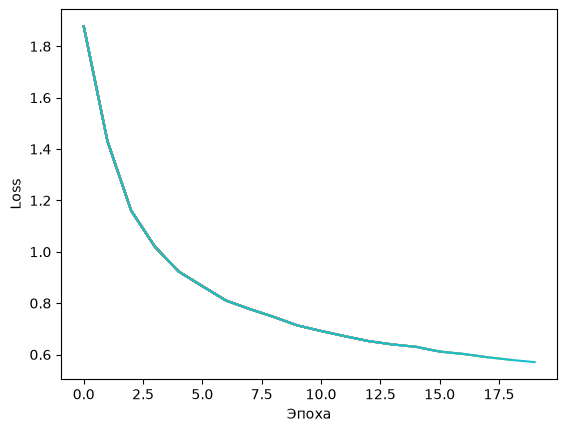

In [18]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 1e-3, 1e-3, 1e-3)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.861242023020773, val_acc: 0.47259998321533203, val_loss: 1.436669950243793
epoch: 2, train loss: 1.4734451384477256, val_acc: 0.609499990940094, val_loss: 1.0741510594947428
epoch: 3, train loss: 1.1932795090089603, val_acc: 0.6714000105857849, val_loss: 0.9077556948118572
epoch: 4, train loss: 1.0246111431986722, val_acc: 0.7094999551773071, val_loss: 0.8277653991421566
epoch: 5, train loss: 0.9392180648737815, val_acc: 0.708299994468689, val_loss: 0.8030781964712506
epoch: 6, train loss: 0.8673465877142154, val_acc: 0.7623999714851379, val_loss: 0.681745991299424
epoch: 7, train loss: 0.8184471198823005, val_acc: 0.7590999603271484, val_loss: 0.6928164630751067
epoch: 8, train loss: 0.7784354220348829, val_acc: 0.780299961566925, val_loss: 0.6322067263005655
epoch: 9, train loss: 0.7456768954974752, val_acc: 0.7737999558448792, val_loss: 0.6743812455406671
epoch: 10, train loss: 0.7180380069973068, val_acc: 0.8000999689102173, val_loss: 0.582010971971705
epoch

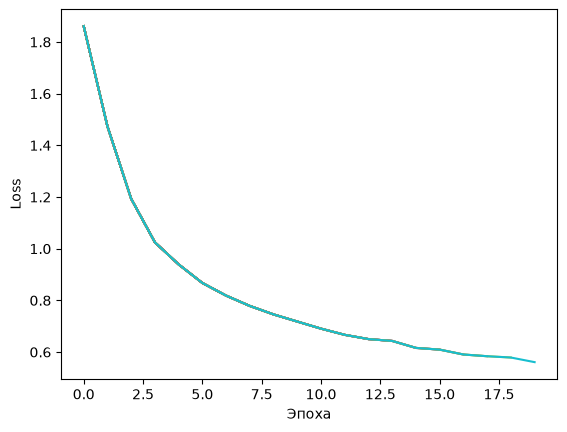

In [19]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 1e-3, 0, 0)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8281244941041475, val_acc: 0.5044000148773193, val_loss: 1.3453036260001268
epoch: 2, train loss: 1.4061878199235645, val_acc: 0.6087999939918518, val_loss: 1.0974327627616594
epoch: 3, train loss: 1.1563538200795764, val_acc: 0.6757000088691711, val_loss: 0.9038552083546603
epoch: 4, train loss: 1.031717542437354, val_acc: 0.7109999656677246, val_loss: 0.8300818008712575
epoch: 5, train loss: 0.9340146423644616, val_acc: 0.7437999844551086, val_loss: 0.7292913424817822
epoch: 6, train loss: 0.8790896549792299, val_acc: 0.7441999912261963, val_loss: 0.7191267405884175
epoch: 7, train loss: 0.8322806015219814, val_acc: 0.7610999941825867, val_loss: 0.6929229131982296
epoch: 8, train loss: 0.7874756936014881, val_acc: 0.7791999578475952, val_loss: 0.6686018512973303
epoch: 9, train loss: 0.7557643122651679, val_acc: 0.7410999536514282, val_loss: 0.7565232666232918
epoch: 10, train loss: 0.7292107601655422, val_acc: 0.7694000005722046, val_loss: 0.6816409913044942


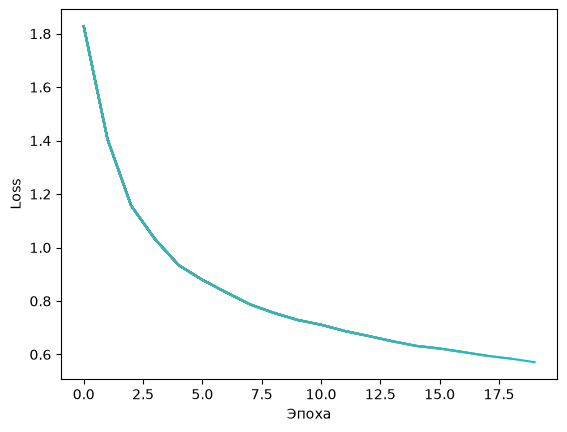

In [20]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 0, 1e-3, 0)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.873040453638698, val_acc: 0.47669997811317444, val_loss: 1.4192602362813829
epoch: 2, train loss: 1.4338523438170563, val_acc: 0.5989999771118164, val_loss: 1.1220470598981351
epoch: 3, train loss: 1.1734713570322657, val_acc: 0.6633999943733215, val_loss: 0.9133443191081663
epoch: 4, train loss: 1.0323876764098574, val_acc: 0.6787999868392944, val_loss: 0.901791555972039
epoch: 5, train loss: 0.9389314304844203, val_acc: 0.7511000037193298, val_loss: 0.7290018789375885
epoch: 6, train loss: 0.8729708070603991, val_acc: 0.7366999983787537, val_loss: 0.7513800037058094
epoch: 7, train loss: 0.8280297121937582, val_acc: 0.7644000053405762, val_loss: 0.7002163672749
epoch: 8, train loss: 0.7874609422050679, val_acc: 0.7712000012397766, val_loss: 0.6649622675738757
epoch: 9, train loss: 0.7494164903195943, val_acc: 0.7924999594688416, val_loss: 0.6028215704084952
epoch: 10, train loss: 0.7240768712984013, val_acc: 0.7558000087738037, val_loss: 0.7072791121428526
epo

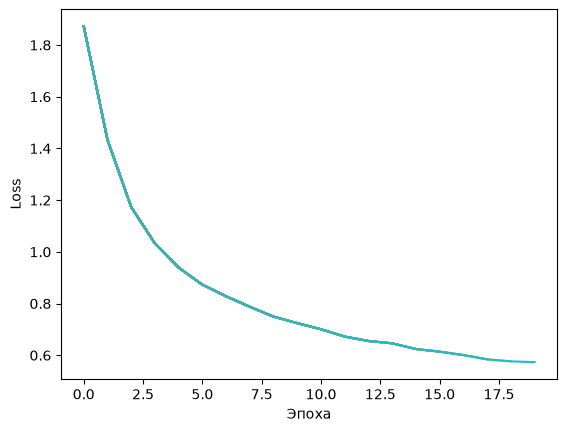

In [21]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 0, 0, 1e-3)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.848871355245911, val_acc: 0.49779999256134033, val_loss: 1.3684268284447585
epoch: 2, train loss: 1.3871777917968107, val_acc: 0.6261999607086182, val_loss: 1.032112146480174
epoch: 3, train loss: 1.1408777720106007, val_acc: 0.6773999929428101, val_loss: 0.9060065391697462
epoch: 4, train loss: 1.0076715908253413, val_acc: 0.7038999795913696, val_loss: 0.8495926675917227
epoch: 5, train loss: 0.9257806642118053, val_acc: 0.7369999885559082, val_loss: 0.7422585045989556
epoch: 6, train loss: 0.8788155259150995, val_acc: 0.7468000054359436, val_loss: 0.7418285125418554
epoch: 7, train loss: 0.8429859940317755, val_acc: 0.7390999794006348, val_loss: 0.7373696580717836
epoch: 8, train loss: 0.8298267092524777, val_acc: 0.7599999904632568, val_loss: 0.7032431533819512
epoch: 9, train loss: 0.806806937651381, val_acc: 0.7558000087738037, val_loss: 0.7084441837630694
epoch: 10, train loss: 0.7961417439841186, val_acc: 0.7742999792098999, val_loss: 0.673253790487217
ep

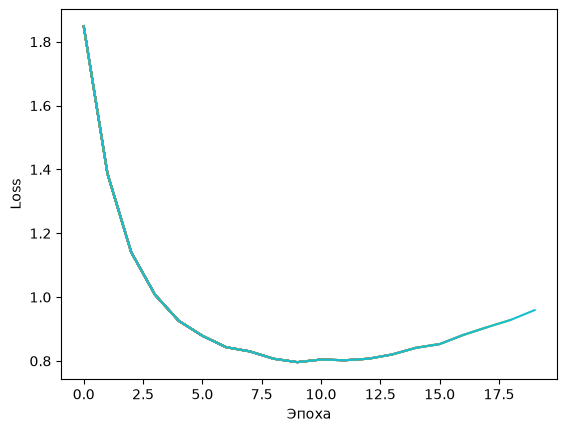

In [22]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 1e-2, 1e-2, 1e-2)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8827729740740775, val_acc: 0.43939998745918274, val_loss: 1.4762819432005096
epoch: 2, train loss: 1.4571324517844353, val_acc: 0.5927000045776367, val_loss: 1.1794940436942667
epoch: 3, train loss: 1.191543239473305, val_acc: 0.6520000100135803, val_loss: 0.9917207141465778
epoch: 4, train loss: 1.0440296558752626, val_acc: 0.665399968624115, val_loss: 0.9481356626824488
epoch: 5, train loss: 0.9508324516406825, val_acc: 0.7287999987602234, val_loss: 0.7676849410503725
epoch: 6, train loss: 0.8826595299227148, val_acc: 0.7532999515533447, val_loss: 0.7166428792325756
epoch: 7, train loss: 0.8334980288798124, val_acc: 0.746399998664856, val_loss: 0.7274822456927239
epoch: 8, train loss: 0.7955096970173463, val_acc: 0.7770999670028687, val_loss: 0.6469738079777246
epoch: 9, train loss: 0.7672689636586495, val_acc: 0.774899959564209, val_loss: 0.6525932127916361
epoch: 10, train loss: 0.7356884993007377, val_acc: 0.7960000038146973, val_loss: 0.6034864258917072
ep

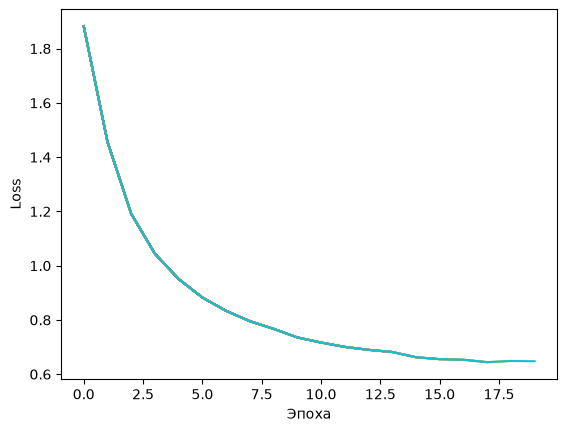

In [23]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 1e-2, 0, 0)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.805291974079281, val_acc: 0.4950999915599823, val_loss: 1.3694780597203895
epoch: 2, train loss: 1.3656150299390768, val_acc: 0.5956000089645386, val_loss: 1.1348052153104469
epoch: 3, train loss: 1.1250772121542933, val_acc: 0.6636999845504761, val_loss: 0.9467375550089003
epoch: 4, train loss: 0.9937620306731948, val_acc: 0.717799961566925, val_loss: 0.7960776520680778
epoch: 5, train loss: 0.9126553247639253, val_acc: 0.7389999628067017, val_loss: 0.7363329220421707
epoch: 6, train loss: 0.8569019877483505, val_acc: 0.7368999719619751, val_loss: 0.758793372142164
epoch: 7, train loss: 0.8182544144238711, val_acc: 0.7561999559402466, val_loss: 0.6975405514240265
epoch: 8, train loss: 0.7855046467756661, val_acc: 0.7742999792098999, val_loss: 0.6771199152439455
epoch: 9, train loss: 0.7637222613078695, val_acc: 0.7827999591827393, val_loss: 0.6268752402142633
epoch: 10, train loss: 0.7464219158037457, val_acc: 0.7782999873161316, val_loss: 0.6371446029294895
ep

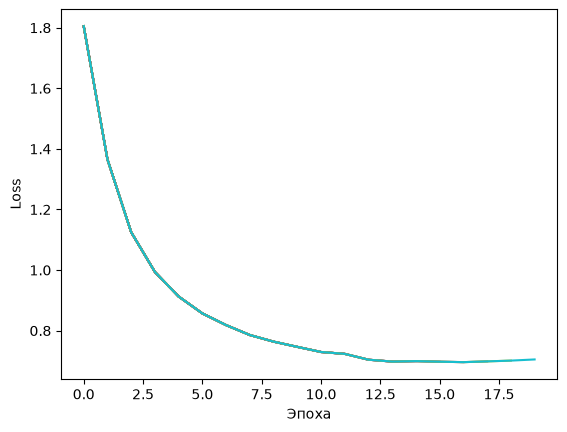

In [24]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 0, 1e-2, 0)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8665503452621968, val_acc: 0.4193999767303467, val_loss: 1.5517715366580818
epoch: 2, train loss: 1.408148461439178, val_acc: 0.5891000032424927, val_loss: 1.1341537599322162
epoch: 3, train loss: 1.1295643023626971, val_acc: 0.686199963092804, val_loss: 0.8847934973390796
epoch: 4, train loss: 0.9888897732291096, val_acc: 0.7116999626159668, val_loss: 0.8106125706358801
epoch: 5, train loss: 0.9078705994959299, val_acc: 0.7538999915122986, val_loss: 0.7231437805332716
epoch: 6, train loss: 0.8622052953057158, val_acc: 0.7418999671936035, val_loss: 0.7330178120468236
epoch: 7, train loss: 0.8163259469559005, val_acc: 0.7682999968528748, val_loss: 0.664174341702763
epoch: 8, train loss: 0.7946411788425458, val_acc: 0.7505999803543091, val_loss: 0.7237294602997696
epoch: 9, train loss: 0.7613387205664804, val_acc: 0.7777999639511108, val_loss: 0.6611147556878343
epoch: 10, train loss: 0.7471138706820483, val_acc: 0.780299961566925, val_loss: 0.6538056829307652
epo

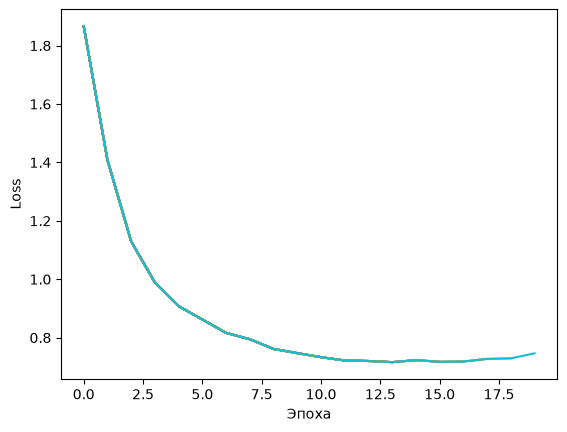

In [25]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 0, 0, 1e-2)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8532410214821344, val_acc: 0.4708999991416931, val_loss: 1.4372887732107429
epoch: 2, train loss: 1.391823481804121, val_acc: 0.6172999739646912, val_loss: 1.1157324495194834
epoch: 3, train loss: 1.1421202578684952, val_acc: 0.6851999759674072, val_loss: 0.8853287244144874
epoch: 4, train loss: 1.0045535988862593, val_acc: 0.7127999663352966, val_loss: 0.8078636783587781
epoch: 5, train loss: 0.9181567574836319, val_acc: 0.729200005531311, val_loss: 0.7675515684900405
epoch: 6, train loss: 0.8653930151454928, val_acc: 0.7579999566078186, val_loss: 0.7179238652881188
epoch: 7, train loss: 0.8182665635322197, val_acc: 0.7497000098228455, val_loss: 0.7375009603138212
epoch: 8, train loss: 0.7841674688528992, val_acc: 0.7802000045776367, val_loss: 0.6356104125704947
epoch: 9, train loss: 0.7514710427283936, val_acc: 0.7917999625205994, val_loss: 0.6185691409473177
epoch: 10, train loss: 0.7141637105592458, val_acc: 0.7893999814987183, val_loss: 0.603162074390846
ep

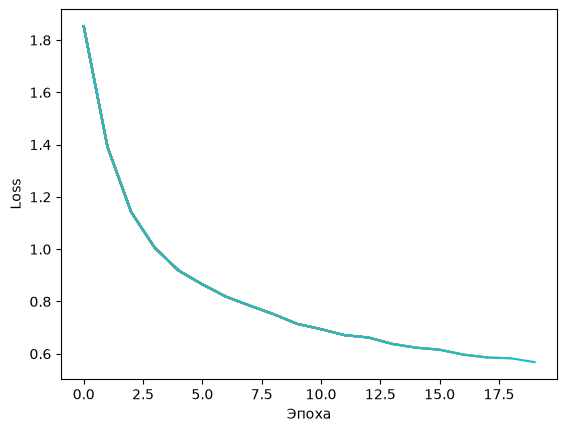

In [27]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 0, 0, 1e-4)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8607565931837602, val_acc: 0.4805999994277954, val_loss: 1.4499324258369735
epoch: 2, train loss: 1.4496157957969076, val_acc: 0.5918999910354614, val_loss: 1.1319495892222924
epoch: 3, train loss: 1.1897121905441552, val_acc: 0.661799967288971, val_loss: 0.9413453529152689
epoch: 4, train loss: 1.0561328164599144, val_acc: 0.7091000080108643, val_loss: 0.8208632257920278
epoch: 5, train loss: 0.9635850709558524, val_acc: 0.7254999876022339, val_loss: 0.794325248350071
epoch: 6, train loss: 0.8911964509133261, val_acc: 0.7337999939918518, val_loss: 0.7658419141286537
epoch: 7, train loss: 0.842947394151529, val_acc: 0.7594999670982361, val_loss: 0.6810972833935218
epoch: 8, train loss: 0.793646410155281, val_acc: 0.7716999650001526, val_loss: 0.6629353241075443
epoch: 9, train loss: 0.7679083413293708, val_acc: 0.7669999599456787, val_loss: 0.663663053814369
epoch: 10, train loss: 0.7361810916101635, val_acc: 0.792199969291687, val_loss: 0.6033662980115866
epoch

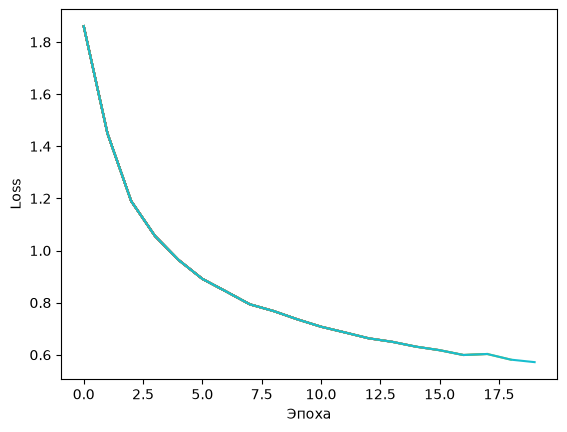

In [28]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20, 1e-4, 1e-4, 1e-4)

print('Время обучения', time.time() - start)